In [1]:
## importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [2]:
df = pd.read_excel('finalforms.xlsx')

In [3]:
# pd.set_option('display.max_columns', None)
pd.set_option('display.max_columns',None)

In [4]:
print(df.shape)
# print(df.head())
df.columns[18]

(62, 104)


'Upon arrival, I prefer to interact with a human staff member rather than a digital system.'

In [5]:
# Clean column names: strip spaces, replace line breaks, compress spaces
df.columns = (
    df.columns
    .str.replace("\n", " ", regex=False)
    .str.replace("\r", " ", regex=False)
    .str.strip()
    .str.replace(" +", " ", regex=True)
)



In [6]:
pd.set_option('display.max_columns',None)

In [7]:
df

,ID,Start time,Completion time,Email,Name,Last modified time,I consent to processing my personal data gathered during the research in the way described in the information sheet.,I consent to retaining research data gathered from me and using this for future research in the field of Computer Science and Mathematics in which recognized ethical standards for scientific resea...,"I consent to making research data gathered from me available in anonymized form via a repository, namely 4TU.ResearchData repository for the purpose of retaining the data and using it for future ...",Do you consent to participate in this study?,Date,"When visiting restaurants, which types of systems have you used? (Select all that applies)",2,Human waiter,Digital screen (tablet / kiosk / QR code / app),Voice-based system (robot / assistant),"Please describe, in your own words, what aspects of a restaurant visit such as entering, being seated, dining, or paying make the overall experience feel smooth or frustrating.","When dining at a restaurant, what is your preferred way to place an order?","Upon arrival, I prefer to interact with a human staff member rather than a digital system.",It feels easier to know what to do when a person guides me upon arrival,Personal interaction with staff at arrival makes the dining experience feel more genuine,It is easier to understand menu items when a person explains them,I like when a staff member helps me explore the menu or suggests dishes,I trust human staff more than a digital system to provide accurate menu information,I enjoy hearing about dishes from a person rather than reading them on a screen,"When a digital system fails, having human staff as a fallback makes me feel supported",I like having the option of human assistance while using a digital system,It is easier to explain my dietary preferences or special needs to a person,It is easier to change or adjust my order when interacting with human staff,I feel reassured when a person confirms my customized order verbally,It is easier to get assistance during the meal from human staff than from a digital system,Human staff are better at judging the right time to bring the next course than digital systems,I feel more comfortable communicating personal or dietary needs to a person than through a digital device,Being checked on by human staff during the meal makes the experience feel more personal,It is easier to ask follow-up questions about dishes when speaking to a person,I trust human staff to handle payments more accurately than a digital system,It is easier to clarify billing or payment questions with a person,"If a payment issue occurs, I believe human staff can resolve it more easily than a digital system",It is easier to understand the bill when a person explains what I am paying for,Having a person handle payment makes me feel more confident and reassured about the transaction,I feel more in control of my payment when interacting with a person rather than a digital system,I rarely need help from staff when using digital systems,It is easy to know how to begin ordering using a digital system,It is easy to share my seating preferences when booking digitally,It is easy to customize my order when using a digital system,"If something goes wrong, I can easily correct or seek help through the system",Wait time for table,Wait time for food (meals),Wait time for bill,I feel confident about what to do next when ordering through a digital menu,I feel confident finding dishes that fit my diet or allergies,I feel confident making payments through a digital system,I feel comfortable paying without staff involvement,I prefer to ask staff only for special or complex requests rather than routine actions,What are your main concerns or frustrations when using such digital systems?,I would feel comfortable speaking to a voice-based system in a restaurant,Being greeted or guided by a voice-enabled robot would feel pleasant and welcoming,"Browsing or selecting menu items by speak

In [16]:
likert_cols = [
    "Upon arrival, I prefer to interact with a human staff member rather than a digital system",
    "It feels easier to know what to do when a person guides me upon arrival",
    "Personal interaction with staff at arrival makes the dining experience feel more genuine",
    "It is easier to understand menu items when a person explains them",
    # "I like when a staff member helps me explore the menu or suggests dishes",
    "I trust human staff more than a digital system to provide accurate menu information",
    "I enjoy hearing about dishes from a person rather than reading them on a screen",
    "When a digital system fails, having human staff as a fallback makes me feel supported",
    "I like having the option of human assistance while using a digital system",
    #"It is easier to explain my dietary preferences or special needs to a person",
    "It is easier to change or adjust my order when interacting with human staff",
    "I feel reassured when a person confirms my customized order verbally",
    "It is easier to get assistance during the meal from human staff than from a digital system",
    "Human staff are better at judging the right time to bring the next course than digital systems",
    # "I feel more comfortable communicating personal or dietary needs to a person than through a digital device",
    "Being checked on by human staff during the meal makes the experience feel more personal",
    "It is easier to ask follow-up questions about dishes when speaking to a person",
    "I trust human staff to handle payments more accurately than a digital system",
    "It is easier to clarify billing or payment questions with a person",
    "If a payment issue occurs, I believe human staff can resolve it more easily than a digital system",
    "It is easier to understand the bill when a person explains what I am paying for",
    "Having a person handle payment makes me feel more confident and reassured about the transaction",
    "I feel more in control of my payment when interacting with a person rather than a digital system"
]


In [17]:
LIKERT_ORDER = {
    "strongly disagree": 1,
    "disagree": 2,
    "slightly disagree": 3,
    "slightly agree": 4,
    "agree": 5,
    "strongly agree": 6,
}


In [18]:
[col for col in likert_cols if col not in df.columns]


[]

In [19]:
# print(df.columns.tolist())


In [20]:
#[col for col in likert_cols if col not in df.columns]

df[likert_cols] = df[likert_cols].apply(lambda col: col.str.lower())


In [21]:
# 2. Make column names clean (optional but recommended)
df.columns = df.columns.str.strip().str.rstrip(".")

# 3. Check which names in likert_cols are incorrect
not_in_df = [col for col in likert_cols if col not in df.columns]
print("Columns not found:", not_in_df)

# 4. Convert all Likert columns to lowercase text
df[likert_cols] = df[likert_cols].apply(lambda col: col.str.lower())

# 5. Map text → numeric values
df[likert_cols] = df[likert_cols].replace(LIKERT_ORDER)

# 6. Run Spearman correlation matrix
corr = df[likert_cols].corr(method="spearman")

corr

Columns not found: []


,"Upon arrival, I prefer to interact with a human staff member rather than a digital system",It feels easier to know what to do when a person guides me upon arrival,Personal interaction with staff at arrival makes the dining experience feel more genuine,It is easier to understand menu items when a person explains them,I trust human staff more than a digital system to provide accurate menu information,I enjoy hearing about dishes from a person rather than reading them on a screen,"When a digital system fails, having human staff as a fallback makes me feel supported",I like having the option of human assistance while using a digital system,It is easier to change or adjust my order when interacting with human staff,I feel reassured when a person confirms my customized order verbally,It is easier to get assistance during the meal from human staff than from a digital system,Human staff are better at judging the right time to bring the next course than digital systems,Being checked on by human staff during the meal makes the experience feel more personal,It is easier to ask follow-up questions about dishes when speaking to a person,I trust human staff to handle payments more accurately than a digital system,It is easier to clarify billing or payment questions with a person,"If a payment issue occurs, I believe human staff can resolve it more easily than a digital system",It is easier to understand the bill when a person explains what I am paying for,Having a person handle payment makes me feel more confident and reassured about the transaction,I feel more in control of my payment when interacting with a person rather than a digital system
"Upon arrival, I prefer to interact with a human staff member rather than a digital system",1.000000,0.740870,0.616928,0.315323,0.290442,0.332638,0.379735,0.443415,0.368574,0.346328,0.652788,0.538762,0.668572,0.443848,0.250173,0.427212,0.420498,0.361721,0.321887,0.326489
It feels easier to know what to do when a person guides me upon arrival,0.740870,1.000000,0.733021,0.334550,0.383196,0.558700,0.457092,0.436939,0.343411,0.404654,0.603982,0.606653,0.554916,0.562586,0.336037,0.530969,0.519532,0.507983,0.441750,0.440015
Personal interaction with staff at arrival makes the dining experience feel more genuine,0.616928,0.733021,1.000000,0.466265,0.489539,0.581602,0.446999,0.368121,0.391316,0.360834,0.707708,0.594928,0.471906,0.470993,0.390482,0.561065,0.559803,0.487926,0.530712,0.528217
It is easier to understand menu items when a person explains them,0.315323,0.334550,0.466265,1.000000,0.491142,0.629885,0.216618,0.191158,0.351558,0.284147,0.459746,0.365387,0.491975,0.497061,0.011688,0.257396,0.440229,0.039963,0.184894,0.218711
I trust human staff more than a digital system to provide accurate menu information,0.290442,0.383196,0.489539,0.491142,1.000000,0.696814,0.133660,0.130622,0.233151,0.529890,0.413050,0.300876,0.358344,0.306397,0.440667,0.299595,0.308463,0.407297,0.492373,0.500243
I enjoy hearing about dishes from a person rather than reading them on a screen,0.332638,0.558700,0.581602,0.629885,0.696814,1.000000,0.105006,0.221764,0.314069,0.376014,0.468869,0.390425,0.426065,0.442170,0.254242,0.501208,0.372047,0.273128,0.370478,0.374383
"When a digital system fails, having human staff as a fallback makes me feel supported",0.379735,0.457092,0.446999,0.216618,0.133660,0.105006,1.000000,0.401786,0.493019,0.501311,0.380519,0.262425,0.151845,0.490500,0.418045,0.317590,0.432368,0.266529,0.407486,0.172039
I like having the option of human assistance while using a digital system,0.443415,0.436939,0.368121,0.191158,0.130622,0.221764,0.401786,1.000000,0.468890,0.128318,0.365764,0.286824,0.336362,0.318203,0.328561,0.309647,0.422782,0.052142,0.271605,0.166275
It is easier to change or adjust my order when interacting with human staff,0.368574,0.343411,0.391316,0.351558,0.233151,0.314069,0.493019,0.468890,1.000000,0.402555,0.478155,0.434674,0.317242,0.661827,0.393044,0.416531,0.716946,0.235358,0.307176,0.24562

In [22]:
df[likert_cols]

,"Upon arrival, I prefer to interact with a human staff member rather than a digital system",It feels easier to know what to do when a person guides me upon arrival,Personal interaction with staff at arrival makes the dining experience feel more genuine,It is easier to understand menu items when a person explains them,I trust human staff more than a digital system to provide accurate menu information,I enjoy hearing about dishes from a person rather than reading them on a screen,"When a digital system fails, having human staff as a fallback makes me feel supported",I like having the option of human assistance while using a digital system,It is easier to change or adjust my order when interacting with human staff,I feel reassured when a person confirms my customized order verbally,It is easier to get assistance during the meal from human staff than from a digital system,Human staff are better at judging the right time to bring the next course than digital systems,Being checked on by human staff during the meal makes the experience feel more personal,It is easier to ask follow-up questions about dishes when speaking to a person,I trust human staff to handle payments more accurately than a digital system,It is easier to clarify billing or payment questions with a person,"If a payment issue occurs, I believe human staff can resolve it more easily than a digital system",It is easier to understand the bill when a person explains what I am paying for,Having a person handle payment makes me feel more confident and reassured about the transaction,I feel more in control of my payment when interacting with a person rather than a digital system
0,2.0,5.0,5.0,5.0,2.0,3.0,6.0,4.0,5.0,6.0,6.0,6.0,4.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0
3,6.0,6.0,6.0,6.0,5.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,4.0,5.0,6.0,5.0,6.0,6.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,5.0,5.0,4.0,4.0,3.0,2.0,6.0,5.0,4.0,6.0,3.0,NaN,2.0,5.0,2.0,2.0,3.0,3.0,2.0,3.0


In [23]:
# corr.to_csv("corr_matrix.csv")

corr.loc["Upon arrival, I prefer to interact with a human staff member rather than a digital system"]



Upon arrival, I prefer to interact with a human staff member rather than a digital system            1.000000
It feels easier to know what to do when a person guides me upon arrival                              0.740870
Personal interaction with staff at arrival makes the dining experience feel more genuine             0.616928
It is easier to understand menu items when a person explains them                                    0.315323
I trust human staff more than a digital system to provide accurate menu information                  0.290442
I enjoy hearing about dishes from a person rather than reading them on a screen                      0.332638
When a digital system fails, having human staff as a fallback makes me feel supported                0.379735
I like having the option of human assistance while using a digital system                            0.443415
It is easier to change or adjust my order when interacting with human staff                          0.368574
I feel rea

In [24]:
corr.loc["It feels easier to know what to do when a person guides me upon arrival"]


Upon arrival, I prefer to interact with a human staff member rather than a digital system            0.740870
It feels easier to know what to do when a person guides me upon arrival                              1.000000
Personal interaction with staff at arrival makes the dining experience feel more genuine             0.733021
It is easier to understand menu items when a person explains them                                    0.334550
I trust human staff more than a digital system to provide accurate menu information                  0.383196
I enjoy hearing about dishes from a person rather than reading them on a screen                      0.558700
When a digital system fails, having human staff as a fallback makes me feel supported                0.457092
I like having the option of human assistance while using a digital system                            0.436939
It is easier to change or adjust my order when interacting with human staff                          0.343411
I feel rea

In [25]:
row1 = "It feels easier to know what to do when a person guides me upon arrival"
row2 = "Upon arrival, I prefer to interact with a human staff member rather than a digital system"


In [26]:
corr.loc[row1].corr(corr.loc[row2])
#Do Item 1 and Item 2 behave similarly across all 23 items?


0.7941736245354957

C:\Users\20236189\AppData\Local\Temp\ipykernel_26556\961694264.py:5: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = sch.linkage(distance, method='ward')
C:\Users\20236189\AppData\Local\Temp\ipykernel_26556\961694264.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


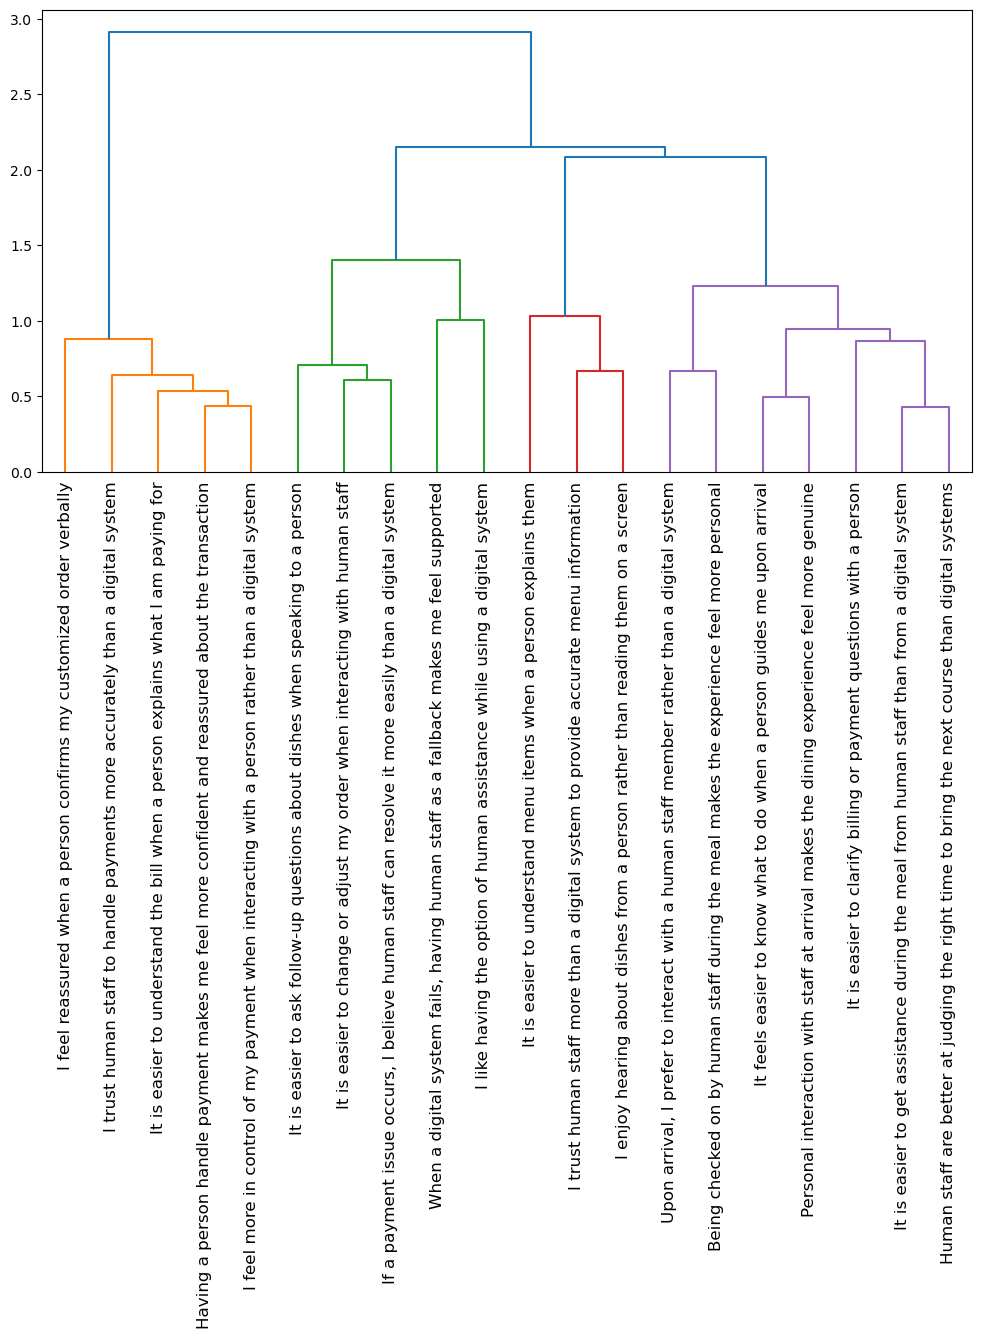

In [27]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

distance = 1 - corr
link = sch.linkage(distance, method='ward')

plt.figure(figsize=(12, 6))
sch.dendrogram(link, labels=corr.columns, leaf_rotation=90)
plt.tight_layout()
plt.show()


In [28]:
# pip install pingouin


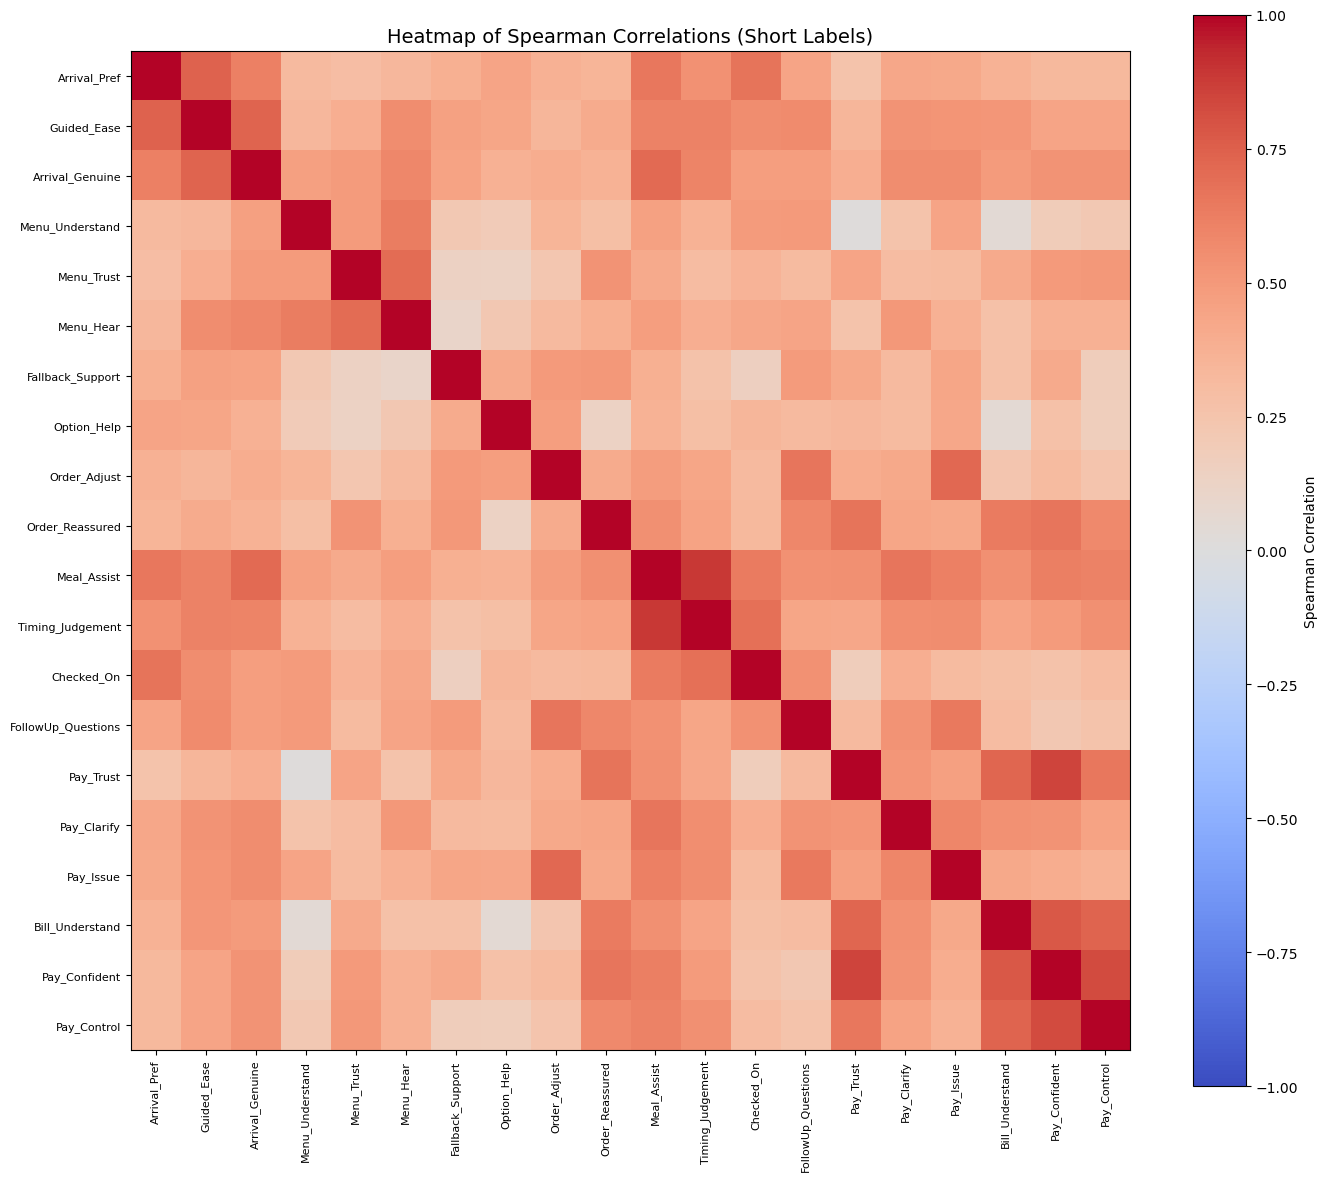

In [29]:
# Create a dictionary mapping long question text → short labels
label_map = {
    "Upon arrival, I prefer to interact with a human staff member rather than a digital system": "Arrival_Pref",
    "It feels easier to know what to do when a person guides me upon arrival": "Guided_Ease",
    "Personal interaction with staff at arrival makes the dining experience feel more genuine": "Arrival_Genuine",
    "It is easier to understand menu items when a person explains them": "Menu_Understand",
    "I like when a staff member helps me explore the menu or suggests dishes": "Menu_Help",
    "I trust human staff more than a digital system to provide accurate menu information": "Menu_Trust",
    "I enjoy hearing about dishes from a person rather than reading them on a screen": "Menu_Hear",
    "When a digital system fails, having human staff as a fallback makes me feel supported": "Fallback_Support",
    "I like having the option of human assistance while using a digital system": "Option_Help",
    "It is easier to explain my dietary preferences or special needs to a person": "Dietary_Explain",
    "It is easier to change or adjust my order when interacting with human staff": "Order_Adjust",
    "I feel reassured when a person confirms my customized order verbally": "Order_Reassured",
    "It is easier to get assistance during the meal from human staff than from a digital system": "Meal_Assist",
    "Human staff are better at judging the right time to bring the next course than digital systems": "Timing_Judgement",
    "I feel more comfortable communicating personal or dietary needs to a person than through a digital device": "Comfort_Dietary",
    "Being checked on by human staff during the meal makes the experience feel more personal": "Checked_On",
    "It is easier to ask follow-up questions about dishes when speaking to a person": "FollowUp_Questions",
    "I trust human staff to handle payments more accurately than a digital system": "Pay_Trust",
    "It is easier to clarify billing or payment questions with a person": "Pay_Clarify",
    "If a payment issue occurs, I believe human staff can resolve it more easily than a digital system": "Pay_Issue",
    "It is easier to understand the bill when a person explains what I am paying for": "Bill_Understand",
    "Having a person handle payment makes me feel more confident and reassured about the transaction": "Pay_Confident",
    "I feel more in control of my payment when interacting with a person rather than a digital system": "Pay_Control"
}

corr_short = corr.rename(index=label_map, columns=label_map)
corr_short


plt.figure(figsize=(14, 12))

plt.imshow(corr_short, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label="Spearman Correlation")

# Set axis labels
plt.xticks(np.arange(len(corr_short.columns)), corr_short.columns, rotation=90, fontsize=8)
plt.yticks(np.arange(len(corr_short.index)), corr_short.index, fontsize=8)

plt.title("Heatmap of Spearman Correlations (Short Labels)", fontsize=14)
plt.tight_layout()
plt.show()


In [30]:
df

,ID,Start time,Completion time,Email,Name,Last modified time,I consent to processing my personal data gathered during the research in the way described in the information sheet,I consent to retaining research data gathered from me and using this for future research in the field of Computer Science and Mathematics in which recognized ethical standards for scientific resea,"I consent to making research data gathered from me available in anonymized form via a repository, namely 4TU.ResearchData repository for the purpose of retaining the data and using it for future",Do you consent to participate in this study?,Date,"When visiting restaurants, which types of systems have you used? (Select all that applies)",2,Human waiter,Digital screen (tablet / kiosk / QR code / app),Voice-based system (robot / assistant),"Please describe, in your own words, what aspects of a restaurant visit such as entering, being seated, dining, or paying make the overall experience feel smooth or frustrating","When dining at a restaurant, what is your preferred way to place an order?","Upon arrival, I prefer to interact with a human staff member rather than a digital system",It feels easier to know what to do when a person guides me upon arrival,Personal interaction with staff at arrival makes the dining experience feel more genuine,It is easier to understand menu items when a person explains them,I like when a staff member helps me explore the menu or suggests dishes,I trust human staff more than a digital system to provide accurate menu information,I enjoy hearing about dishes from a person rather than reading them on a screen,"When a digital system fails, having human staff as a fallback makes me feel supported",I like having the option of human assistance while using a digital system,It is easier to explain my dietary preferences or special needs to a person,It is easier to change or adjust my order when interacting with human staff,I feel reassured when a person confirms my customized order verbally,It is easier to get assistance during the meal from human staff than from a digital system,Human staff are better at judging the right time to bring the next course than digital systems,I feel more comfortable communicating personal or dietary needs to a person than through a digital device,Being checked on by human staff during the meal makes the experience feel more personal,It is easier to ask follow-up questions about dishes when speaking to a person,I trust human staff to handle payments more accurately than a digital system,It is easier to clarify billing or payment questions with a person,"If a payment issue occurs, I believe human staff can resolve it more easily than a digital system",It is easier to understand the bill when a person explains what I am paying for,Having a person handle payment makes me feel more confident and reassured about the transaction,I feel more in control of my payment when interacting with a person rather than a digital system,I rarely need help from staff when using digital systems,It is easy to know how to begin ordering using a digital system,It is easy to share my seating preferences when booking digitally,It is easy to customize my order when using a digital system,"If something goes wrong, I can easily correct or seek help through the system",Wait time for table,Wait time for food (meals),Wait time for bill,I feel confident about what to do next when ordering through a digital menu,I feel confident finding dishes that fit my diet or allergies,I feel confident making payments through a digital system,I feel comfortable paying without staff involvement,I prefer to ask staff only for special or complex requests rather than routine actions,What are your main concerns or frustrations when using such digital systems?,I would feel comfortable speaking to a voice-based system in a restaurant,Being greeted or guided by a voice-enabled robot would feel pleasant and welcoming,"Browsing or selecting menu items by speaking would 

In [31]:
# import pingouin as pg

# red_cols = [
#     "It is easier to clarify billing or payment questions with a person",
#     "It is easier to get assistance during the meal from human staff than from a digital system",
#     "Human staff are better at judging the right time to bring the next course than digital systems",
#     "Upon arrival, I prefer to interact with a human staff member rather than a digital system",
#     "Being checked on by human staff during the meal makes the experience feel more personal",
#     "It feels easier to know what to do when a person guides me upon arrival",
#     "Personal interaction with staff at arrival makes the dining experience feel more genuine",
#     "It is easier to explain my dietary preferences or special needs to a person",
#     "I feel more comfortable communicating personal or dietary needs to a person than through a digital device",
#     "It is easier to ask follow-up questions about dishes when speaking to a person",
#     "I feel reassured when a person confirms my customized order verbally",
#     "It is easier to change or adjust my order when interacting with human staff",
#     "If a payment issue occurs, I believe human staff can resolve it more easily than a digital system",
#     "When a digital system fails, having human staff as a fallback makes me feel supported",
#     "I like having the option of human assistance while using a digital system"    
# ]

# # OPTIONAL: check that all names actually exist in df
# missing = [c for c in red_cols if c not in df.columns]
# print("Missing:", missing)  # should be [] before proceeding

# # Now compute alpha (assuming these columns are already numeric 1–6)
# alpha, ci = pg.cronbach_alpha(data=df[red_cols])
# print("Red Alpha:", alpha)
# print("95% CI:", ci)


# # but I split this because conceptually they were not the same

In [32]:
import pingouin as pg

def cronbach_alpha_for(df, cols):
    """
    df   = your dataframe
    cols = list of column names for the construct
    """
    data = df[cols].dropna()
    alpha, ci = pg.cronbach_alpha(data)
    print(f"Cronbach's alpha for {cols}: {alpha:.3f}")
    print(f"95% CI: {ci}")
    return alpha


In [33]:
arrival_cols = [
    "Upon arrival, I prefer to interact with a human staff member rather than a digital system",
    "It feels easier to know what to do when a person guides me upon arrival",
    "Personal interaction with staff at arrival makes the dining experience feel more genuine",
]

cronbach_alpha_for(df, arrival_cols)


Cronbach's alpha for ['Upon arrival, I prefer to interact with a human staff member rather than a digital system', 'It feels easier to know what to do when a person guides me upon arrival', 'Personal interaction with staff at arrival makes the dining experience feel more genuine']: 0.798
95% CI: [0.64  0.894]


0.7981471816283926

In [34]:
# #Communication & Dietary Comfort
# communication_cols = [
#     # "It is easier to explain my dietary preferences or special needs to a person",
#     # "I feel more comfortable communicating personal or dietary needs to a person than through a digital device",
#     #"It is easier to ask follow-up questions about dishes when speaking to a person",
#     # "I like having the option of human assistance while using a digital system"

# ]

# cronbach_alpha_for(df, communication_cols)


In [35]:
#Meal-Time Human Assistance
meal_cols = [
    "Being checked on by human staff during the meal makes the experience feel more personal",
    "It is easier to get assistance during the meal from human staff than from a digital system",
    "Human staff are better at judging the right time to bring the next course than digital systems",
    "It is easier to change or adjust my order when interacting with human staff",
    "I feel reassured when a person confirms my customized order verbally",
    "I like having the option of human assistance while using a digital system",
    "When a digital system fails, having human staff as a fallback makes me feel supported",
    "It is easier to ask follow-up questions about dishes when speaking to a person"

]

cronbach_alpha_for(df, meal_cols)


Cronbach's alpha for ['Being checked on by human staff during the meal makes the experience feel more personal', 'It is easier to get assistance during the meal from human staff than from a digital system', 'Human staff are better at judging the right time to bring the next course than digital systems', 'It is easier to change or adjust my order when interacting with human staff', 'I feel reassured when a person confirms my customized order verbally', 'I like having the option of human assistance while using a digital system', 'When a digital system fails, having human staff as a fallback makes me feel supported', 'It is easier to ask follow-up questions about dishes when speaking to a person']: 0.852
95% CI: [0.754 0.921]


0.8517833553500661

In [36]:
#human fallback and trust
fallback_cols = [
    "It is easier to clarify billing or payment questions with a person",
    "If a payment issue occurs, I believe human staff can resolve it more easily than a digital system",
    #"It is easier to ask follow-up questions about dishes when speaking to a person"
    #"When a digital system fails, having human staff as a fallback makes me feel supported",
]

cronbach_alpha_for(df, fallback_cols)


Cronbach's alpha for ['It is easier to clarify billing or payment questions with a person', 'If a payment issue occurs, I believe human staff can resolve it more easily than a digital system']: 0.747
95% CI: [0.483 0.877]


0.7474426005910433

In [37]:
import pingouin as pg

green_cols = [
    "It is easier to understand menu items when a person explains them",
  
    # "I like when a staff member helps me explore the menu or suggests dishes",
    "I trust human staff more than a digital system to provide accurate menu information",
    "I enjoy hearing about dishes from a person rather than reading them on a screen"   
]

# OPTIONAL: check that all names actually exist in df
missing = [c for c in green_cols if c not in df.columns]
print("Missing:", missing)  # should be [] before proceeding

# Now compute alpha (assuming these columns are already numeric 1–6)
alpha, ci = pg.cronbach_alpha(data=df[green_cols])
print("Green Alpha:", alpha)
print("95% CI:", ci)


Missing: []
Green Alpha: 0.8047455144635663
95% CI: [0.702 0.876]


In [38]:
import pingouin as pg

Percived_value_of_human_led_menu_explaination = [
    #"It is easier to understand menu items when a person explains them",
  
    # "I like when a staff member helps me explore the menu or suggests dishes",
    "I trust human staff more than a digital system to provide accurate menu information",
    "I enjoy hearing about dishes from a person rather than reading them on a screen"   
]

# OPTIONAL: check that all names actually exist in df
missing = [c for c in Percived_value_of_human_led_menu_explaination if c not in df.columns]
print("Missing:", missing)  # should be [] before proceeding

# Now compute alpha (assuming these columns are already numeric 1–6)
alpha, ci = pg.cronbach_alpha(data=df[green_cols])
print("Percived_value_of_human_led_menu_explaination:", alpha)
print("95% CI:", ci)


Missing: []
Percived_value_of_human_led_menu_explaination: 0.8047455144635663
95% CI: [0.702 0.876]


In [39]:
import pingouin as pg

# No shared concpetual similarity
#f α ≥  0.9225255607267622 → good construct

# keep question 1 seperate

# remaining 4 keep seperate


orange_cols = [
    # "I feel reassured when a person confirms my customized order verbally",
    
    "I trust human staff to handle payments more accurately than a digital system",
    "It is easier to understand the bill when a person explains what I am paying for",
    "Having a person handle payment makes me feel more confident and reassured about the transaction",
    "I feel more in control of my payment when interacting with a person rather than a digital system",    
]

# OPTIONAL: check that all names actually exist in df
missing = [c for c in orange_cols if c not in df.columns]
print("Missing:", missing)  # should be [] before proceeding

# Now compute alpha (assuming these columns are already numeric 1–6)
alpha, ci = pg.cronbach_alpha(data=df[orange_cols])
print("Orange Alpha:", alpha)
print("95% CI:", ci)


#Reassurance & Human Accuracy Trust
#"I feel reassured when a person confirms my customized order verbally"

#Menu Guidance & Staff Assistance
#"I trust human staff to handle payments more accurately than a digital system",
#"It is easier to understand the bill when a person explains what I am paying for",
#Having a person handle payment makes me feel more confident and reassured about the transaction",
#"I feel more in control of my payment when interacting with a person rather than a digital system"


Missing: []
Orange Alpha: 0.9260135850218398
95% CI: [0.891 0.952]


In [ ]:
INV_LIKERT_ORDER = {v: k for k, v in LIKERT_ORDER.items()}


# AGREE = ["slightly agree", "agree", "strongly agree"]
# DISAGREE = ["strongly disagree", "disagree", "slightly disagree"]


In [ ]:
INV_LIKERT_ORDER

In [42]:
likert_cols1 = [
    "Upon arrival, I prefer to interact with a human staff member rather than a digital system",
    "It feels easier to know what to do when a person guides me upon arrival",
    "Personal interaction with staff at arrival makes the dining experience feel more genuine",
    "It is easier to understand menu items when a person explains them",
    "I like when a staff member helps me explore the menu or suggests dishes",
    "I trust human staff more than a digital system to provide accurate menu information",
    "I enjoy hearing about dishes from a person rather than reading them on a screen",
    "When a digital system fails, having human staff as a fallback makes me feel supported",
    "I like having the option of human assistance while using a digital system",
    "It is easier to explain my dietary preferences or special needs to a person",
    "It is easier to change or adjust my order when interacting with human staff",
    "I feel reassured when a person confirms my customized order verbally",
    "It is easier to get assistance during the meal from human staff than from a digital system",
    "Human staff are better at judging the right time to bring the next course than digital systems",
    "I feel more comfortable communicating personal or dietary needs to a person than through a digital device",
    "Being checked on by human staff during the meal makes the experience feel more personal",
    "It is easier to ask follow-up questions about dishes when speaking to a person",
    "I trust human staff to handle payments more accurately than a digital system",
    "It is easier to clarify billing or payment questions with a person",
    "If a payment issue occurs, I believe human staff can resolve it more easily than a digital system",
    "It is easier to understand the bill when a person explains what I am paying for",
    "Having a person handle payment makes me feel more confident and reassured about the transaction",
    "I feel more in control of my payment when interacting with a person rather than a digital system"
]


In [ ]:
df[likert_cols1] 

In [ ]:
# for col in likert_cols1:
#     df[col] = (
#         df[col]
#         .astype(str)
#         .str.strip()
#         .str.lower()
#         .map(INV_LIKERT_ORDER)
#     )


# df.columns = df.columns.str.strip().str.rstrip(".")



In [ ]:
df

In [40]:
LIKERT_MAP_NUM_TO_STR = {
    1: "strongly disagree",
    2: "disagree",
    3: "slightly disagree",
    4: "slightly agree",
    5: "agree",
    6: "strongly agree",
}


In [43]:
for col in likert_cols1:
    df[col] = (
        pd.to_numeric(df[col], errors="coerce")   # ensure numeric
        .map(LIKERT_MAP_NUM_TO_STR)               # convert to text
    )


In [44]:
df["I trust human staff to handle payments more accurately than a digital system"].value_counts(dropna=False)


I trust human staff to handle payments more accurately than a digital system
NaN                  29
disagree             14
slightly agree        6
slightly disagree     5
strongly agree        3
strongly disagree     3
agree                 2
Name: count, dtype: int64

In [45]:
print(df[likert_cols1].head())
print(df[likert_cols1].dtypes)
# 

  Upon arrival, I prefer to interact with a human staff member rather than a digital system  \
0                                           disagree                                          
1                                                NaN                                          
2                                     strongly agree                                          
3                                     strongly agree                                          
4                                                NaN                                          

  It feels easier to know what to do when a person guides me upon arrival  \
0                                              agree                        
1                                                NaN                        
2                                     strongly agree                        
3                                     strongly agree                        
4                                           

In [46]:
print(df["I trust human staff to handle payments more accurately than a digital system"].value_counts(dropna=False))


I trust human staff to handle payments more accurately than a digital system
NaN                  29
disagree             14
slightly agree        6
slightly disagree     5
strongly agree        3
strongly disagree     3
agree                 2
Name: count, dtype: int64


In [47]:
# df

In [48]:
df['Gender'].value_counts()

Gender
Man                  30
Woman                26
Prefer not to say     2
Name: count, dtype: int64

In [49]:
df['Age band'].value_counts()

Age band
25–34    33
35–44    11
45–54     6
55–64     3
18–24     3
65+       2
Name: count, dtype: int64

In [50]:

age = "Age band"
modality = "When dining at a restaurant, what is your preferred way to place an order?"


In [51]:
AGREE = ["slightly agree", "agree", "strongly agree"]
DISAGREE = ["strongly disagree", "disagree", "slightly disagree"]

def compute_overall_sentiment(df, likert_col):
    # drop NA
    series = df[likert_col].dropna()

    total = series.shape[0]
    agree = series.isin(AGREE).sum()
    disagree = series.isin(DISAGREE).sum()

    agree_pct = agree / total * 100
    disagree_pct = disagree / total * 100

    return agree, disagree, total, agree_pct, disagree_pct


In [52]:
for q in arrival_cols:
    agree, disagree, total, agree_pct, disagree_pct = compute_overall_sentiment(df, q)
    print(q)
    print(f"Responses: {total}")
    print(f"Agreement: {agree_pct:.1f}%  |  Disagreement: {disagree_pct:.1f}%\n")


Upon arrival, I prefer to interact with a human staff member rather than a digital system
Responses: 33
Agreement: 93.9%  |  Disagreement: 6.1%

It feels easier to know what to do when a person guides me upon arrival
Responses: 33
Agreement: 93.9%  |  Disagreement: 6.1%

Personal interaction with staff at arrival makes the dining experience feel more genuine
Responses: 33
Agreement: 90.9%  |  Disagreement: 9.1%



In [53]:
LIKERT_ORDER_PLOT = [
    "strongly disagree",
    "disagree",
    "slightly disagree",
    "slightly agree",
    "agree",
    "strongly agree",
]

AGREE = ["slightly agree", "agree", "strongly agree"]
DISAGREE = ["strongly disagree", "disagree", "slightly disagree"]

df = df.apply(lambda col: col.str.lower() if col.dtype == "object" else col)


def plot_checkbox_vs_likert(df, checkbox_col, likert_col,
                            title_prefix="", figsize=(10,4)):

    # --- STEP 1: explode checkbox column to long format ---
    cb = df[checkbox_col].fillna("").str.split(";")
    cb_exploded = cb.explode().str.strip()
    cb_exploded = cb_exploded[cb_exploded != ""]
    df_long = df.loc[cb_exploded.index].copy()
    df_long["checkbox_cat"] = cb_exploded

    # --- STEP 2: crosstab (COUNTS) ---
    ct = pd.crosstab(
        df_long["checkbox_cat"],
        df_long[likert_col]
    )

    # ensure all Likert categories exist & in right order
    for resp in LIKERT_ORDER_PLOT:
        if resp not in ct.columns:
            ct[resp] = 0
    ct = ct[LIKERT_ORDER_PLOT]

    ct_counts = ct.copy()
    total_n_cells = ct_counts.values.sum()   # for global % on segments

    # --- STEP 2b: overall agreement / disagreement for THIS QUESTION ---
    s = df[likert_col].dropna()              # exclude NA
    total_valid = s.shape[0]
    agree_n = s.isin(AGREE).sum()
    disagree_n = s.isin(DISAGREE).sum()

    agree_pct = agree_n / total_valid * 100 if total_valid > 0 else 0
    disagree_pct = disagree_n / total_valid * 100 if total_valid > 0 else 0

    summary_text = (
        f"N = {total_valid}\n"
        f"Agree: {agree_pct:.1f}% (n={agree_n})\n"
        f"Disagree: {disagree_pct:.1f}% (n={disagree_n})"
    )

    # --- STEP 3: plot COUNTS (like your screenshot) ---
    ax = ct_counts.plot(
        kind="barh",
        stacked=True,
        figsize=figsize
    )

    ax.set_xlabel("Percentage")
    ax.set_ylabel(checkbox_col)
    ax.set_title(f"{title_prefix}{likert_col}")

    # global-% labels on each segment (optional – this is what you had)
    for i, row in enumerate(ct_counts.values):
        cum = 0
        for count in row:
            if count > 0:
                pct_global = count / total_n_cells * 100
                ax.text(
                    cum + count / 2,
                    i,
                    f"{pct_global:.1f}%",
                    ha="center", va="center",
                    fontsize=8,
                    color="white" if count > 3 else "black"
                )
            cum += count

    # legend outside
    ax.legend(
        title="Response",
        bbox_to_anchor=(1.35, 1),
        loc="upper left"
    )

    # --- STEP 4: add summary box BESIDE the plot ---
    ax.text(
        1.02, 0.3,                   # x, y in axes coords (just outside right)
        summary_text,
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
    )

    plt.tight_layout()
    plt.show()


In [ ]:

demographic_checkboxes = {
    "Age band": "Age band"
    # "Dining frequency ( Select all that applies)": "Dining frequency",
    # "Typical group size while dining (Select all that applies)": "Typical group size",
    # "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)": "Restaurant setting",
}



arrival_cols = [
    "Upon arrival, I prefer to interact with a human staff member rather than a digital system",
    "It feels easier to know what to do when a person guides me upon arrival",
    "Personal interaction with staff at arrival makes the dining experience feel more genuine",
]

# arrival_cols = [
#     "Upon arrival, I prefer to interact with a human staff member rather than a digital system",
#     "It feels easier to know what to do when a person guides me upon arrival",
#     "Personal interaction with staff at arrival makes the dining experience feel more genuine"
# ]

# Dynamic loop for all demographics × all Likert items
for checkbox_col, demo_label in demographic_checkboxes.items():
    for q in arrival_cols:
        plot_checkbox_vs_likert(
            df,
            checkbox_col=checkbox_col,
            likert_col=q,
            title_prefix=f"Arrival in a restaurant and greeting by human – {demo_label} • "
        )



# Age band
# 25–34    33
# 35–44    11
# 45–54     6
# 55–64     3
# 18–24     3
# 65+       2
# Name: count, dtype: int64

# Most people strongly agree that Upon arrival, I prefer to interact with a human staff member rather than a digital system and everyone from 18-24 agree they want this


In [ ]:


# Your demographic checkbox / category columns
demographic_checkboxes = {
    "Age band": "Age band",
    # "Dining frequency ( Select all that applies)": "Dining frequency",
    # "Typical group size while dining (Select all that applies)": "Typical group size",
    # "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)": "Restaurant setting",
}



meal_assistance = [
    "Being checked on by human staff during the meal makes the experience feel more personal",
    "It is easier to ask follow-up questions about dishes when speaking to a person",
    "It is easier to get assistance during the meal from human staff than from a digital system",
    "Human staff are better at judging the right time to bring the next course than digital systems",
    "It is easier to change or adjust my order when interacting with human staff",
    "I feel reassured when a person confirms my customized order verbally",
    "I like having the option of human assistance while using a digital system",
    "When a digital system fails, having human staff as a fallback makes me feel supported"
]




# Dynamic loop for all demographics × all Likert items
for checkbox_col, demo_label in demographic_checkboxes.items():
    for q in meal_assistance:
        plot_checkbox_vs_likert(
            df,
            checkbox_col=checkbox_col,
            likert_col=q,
            title_prefix=f"Meal_assistance {demo_label} • "
        )

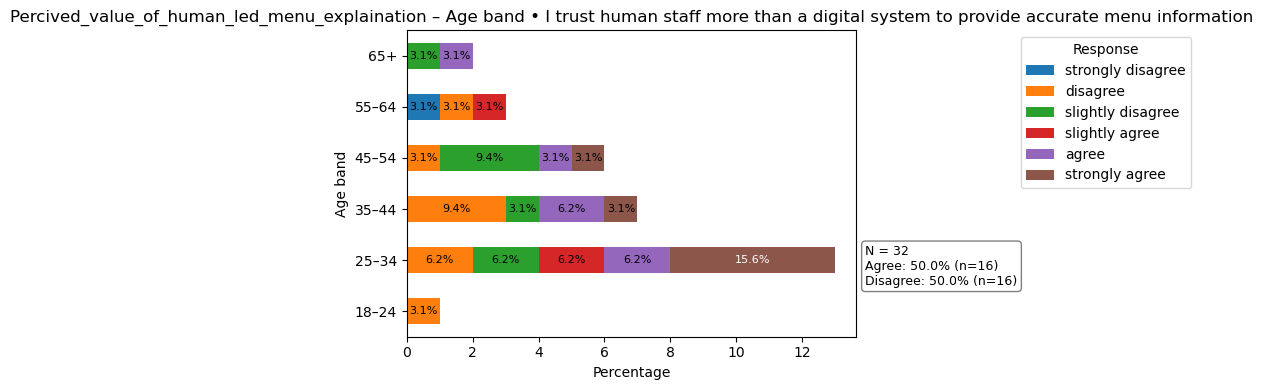

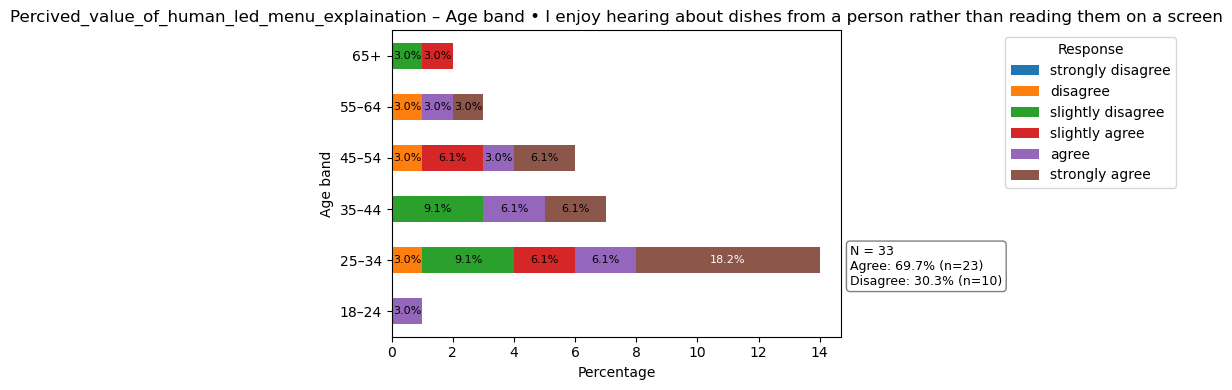

In [54]:
# Your demographic checkbox / category columns
demographic_checkboxes = {
    "Age band": "Age band"
    # "Dining frequency ( Select all that applies)": "Dining frequency",
    # "Typical group size while dining (Select all that applies)": "Typical group size",
    # "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)": "Restaurant setting",
}

# Despite imperfect wording (which is comparitive), people interpreted these three questions in a very consistent way. Ofcourse the definition of consistency
# here is subjective to interpretation...this is a limitation

# 3) Human interaction during the MEAL – HUMAN
Percived_value_of_human_led_menu_explaination = [
    "I trust human staff more than a digital system to provide accurate menu information", 
    "I enjoy hearing about dishes from a person rather than reading them on a screen"
]


# Dynamic loop for all demographics × all Likert items
for checkbox_col, demo_label in demographic_checkboxes.items():
    for q in Percived_value_of_human_led_menu_explaination:
        plot_checkbox_vs_likert(
            df,
            checkbox_col=checkbox_col,
            likert_col=q,
            title_prefix=f"Percived_value_of_human_led_menu_explaination – {demo_label} • "
        )

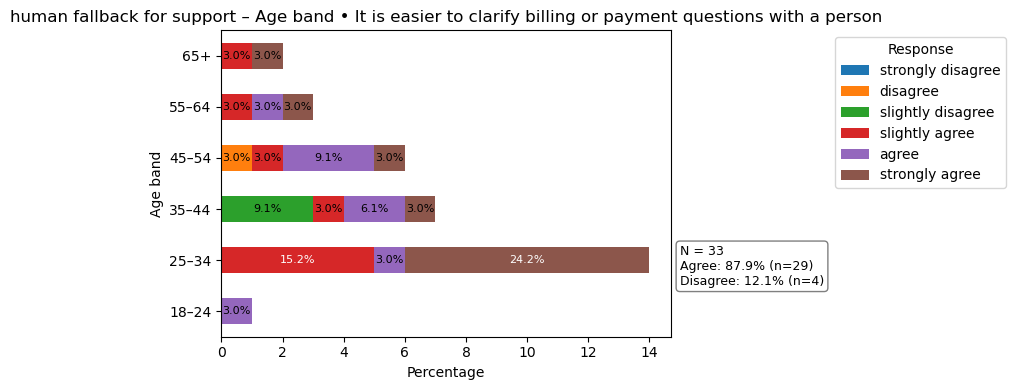

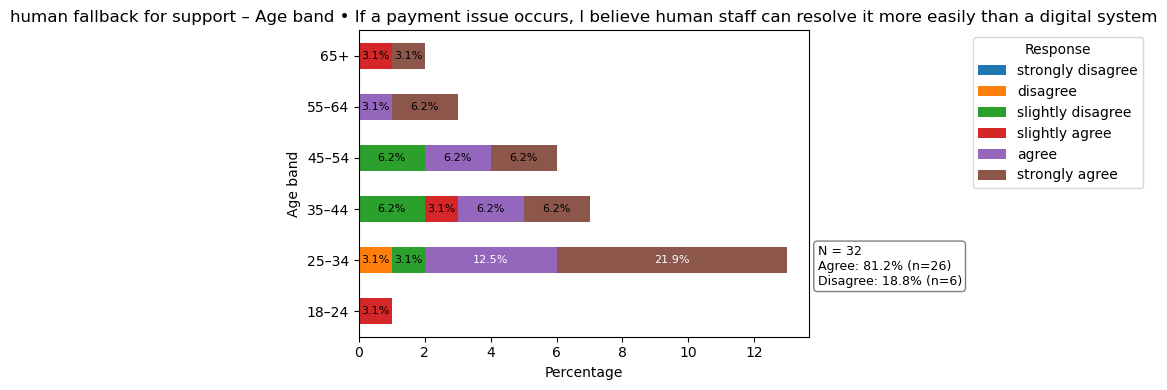

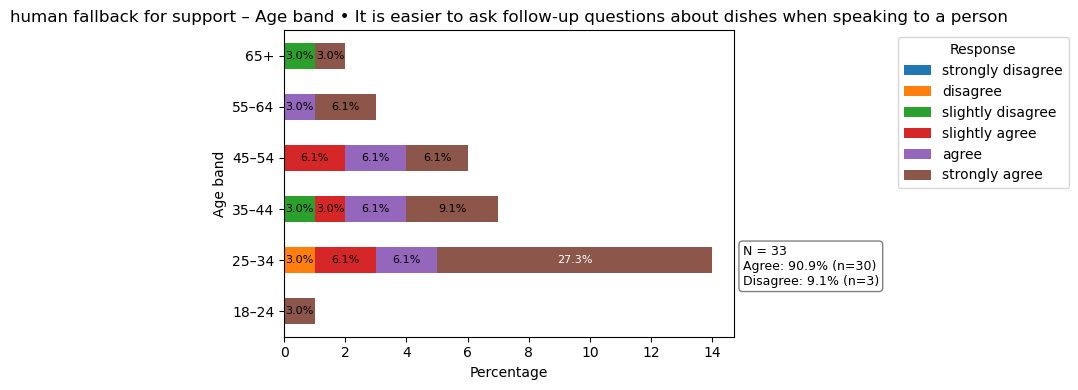

In [57]:
# Your demographic checkbox / category columns
demographic_checkboxes = {
    "Age band": "Age band"
    # "Dining frequency ( Select all that applies)": "Dining frequency",
    # "Typical group size while dining (Select all that applies)": "Typical group size",
    # "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)": "Restaurant setting",
}

# Despite imperfect wording (which is comparitive), people interpreted these three questions in a very consistent way. Ofcourse the definition of consistency
# here is subjective to interpretation...this is a limitation

# 3) Human interaction during the MEAL – HUMAN
human_fallback_for_support = [
    "It is easier to clarify billing or payment questions with a person",
    "If a payment issue occurs, I believe human staff can resolve it more easily than a digital system",
    "It is easier to ask follow-up questions about dishes when speaking to a person"
]

# Dynamic loop for all demographics × all Likert items
for checkbox_col, demo_label in demographic_checkboxes.items():
    for q in human_fallback_for_support:
        plot_checkbox_vs_likert(
            df,
            checkbox_col=checkbox_col,
            likert_col=q,
            title_prefix=f"human fallback for support – {demo_label} • "
        )

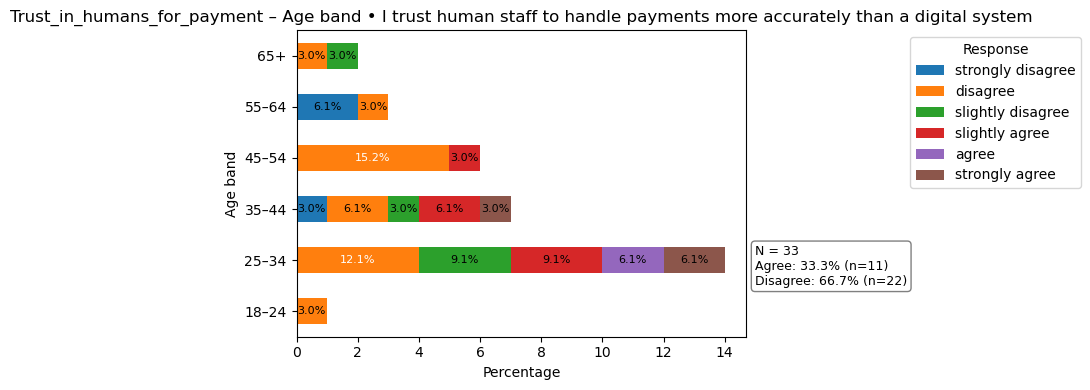

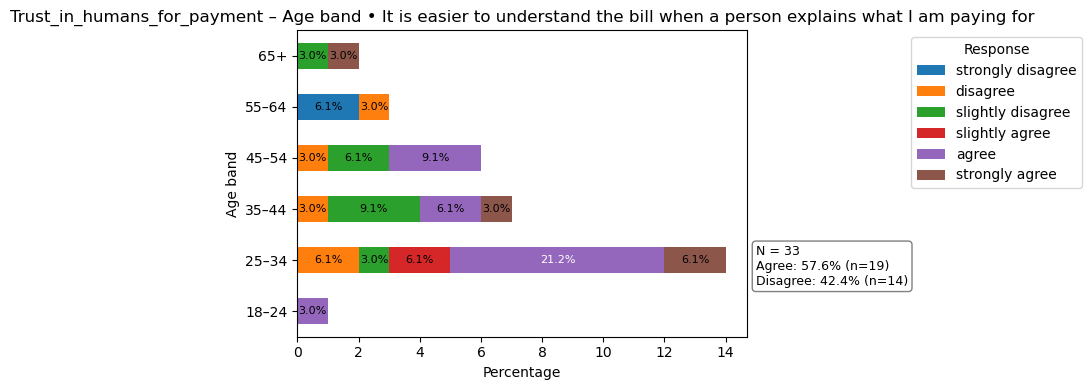

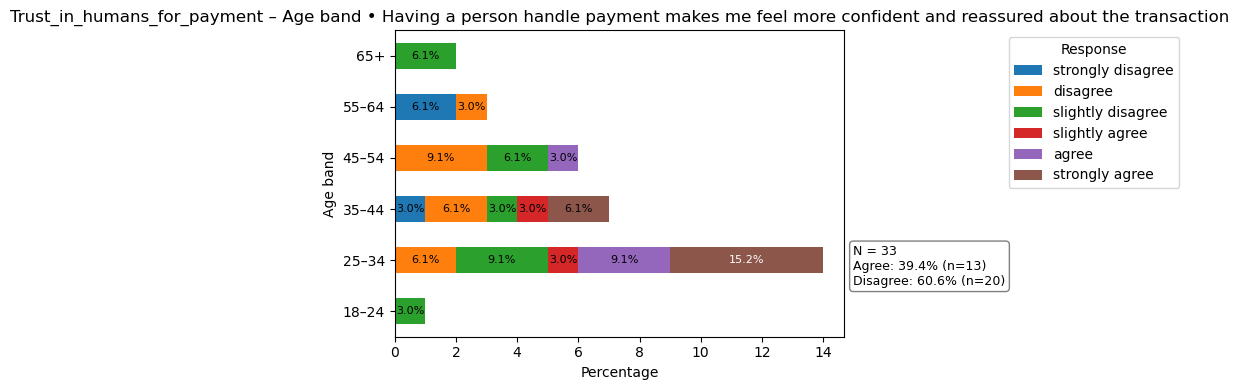

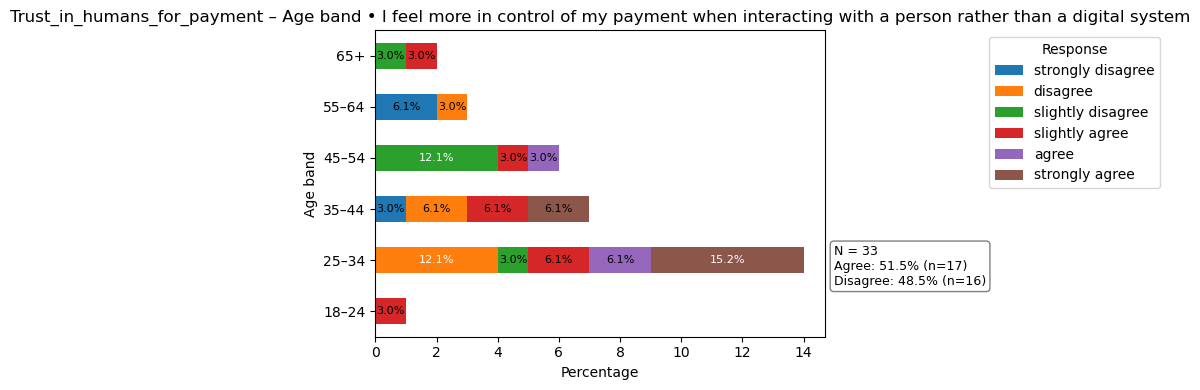

In [58]:
# Your demographic checkbox / category columns
demographic_checkboxes = {
    "Age band": "Age band"
    # "Dining frequency ( Select all that applies)": "Dining frequency",
    # "Typical group size while dining (Select all that applies)": "Typical group size",
    # "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)": "Restaurant setting",
}

# Despite imperfect wording (which is comparitive), people interpreted these three questions in a very consistent way. Ofcourse the definition of consistency
# here is subjective to interpretation...this is a limitation

# 3) Human interaction during the MEAL – HUMAN
Trust_in_humans_for_payment  = [
    "I trust human staff to handle payments more accurately than a digital system",
    "It is easier to understand the bill when a person explains what I am paying for",
    "Having a person handle payment makes me feel more confident and reassured about the transaction",
    "I feel more in control of my payment when interacting with a person rather than a digital system"
]


# Dynamic loop for all demographics × all Likert items
for checkbox_col, demo_label in demographic_checkboxes.items():
    for q in Trust_in_humans_for_payment:
        plot_checkbox_vs_likert(
            df,
            checkbox_col=checkbox_col,
            likert_col=q,
            title_prefix=f"Trust_in_humans_for_payment – {demo_label} • "
        )

In [ ]:
# Your demographic checkbox / category columns
demographic_checkboxes = {
    "Age band": "Age band"
    # "Dining frequency ( Select all that applies)": "Dining frequency",
    # "Typical group size while dining (Select all that applies)": "Typical group size",
    # "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)": "Restaurant setting",
}

# Despite imperfect wording (which is comparitive), people interpreted these three questions in a very consistent way. Ofcourse the definition of consistency
# here is subjective to interpretation...this is a limitation

# 3) Human interaction during the MEAL – HUMAN

Menu_exploration_with_humans = [
    "It is easier to understand menu items when a person explains them",
    #"I like when a staff member helps me explore the menu or suggests dishes",
    "I trust human staff more than a digital system to provide accurate menu information",
    "I enjoy hearing about dishes from a person rather than reading them on a screen"
]


# Dynamic loop for all demographics × all Likert items
for checkbox_col, demo_label in demographic_checkboxes.items():
    for q in Menu_exploration_with_humans:
        plot_checkbox_vs_likert(
            df,
            checkbox_col=checkbox_col,
            likert_col=q,
            title_prefix=f"Menu_exploration_with_humans – {demo_label} • "
        )

In [ ]:
# Your demographic checkbox / category columns
demographic_checkboxes = {
    "Age band": "Age band"
    # "Dining frequency ( Select all that applies)": "Dining frequency",
    # "Typical group size while dining (Select all that applies)": "Typical group size",
    # "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)": "Restaurant setting",
}

# Despite imperfect wording (which is comparitive), people interpreted these three questions in a very consistent way. Ofcourse the definition of consistency
# here is subjective to interpretation...this is a limitation

# 3) Human interaction during the MEAL – HUMAN

Human_payment = [
    "I trust human staff to handle payments more accurately than a digital system",
    "It is easier to understand the bill when a person explains what I am paying for",
    "Having a person handle payment makes me feel more confident and reassured about the transaction",
    "I feel more in control of my payment when interacting with a person rather than a digital system"
]

# Dynamic loop for all demographics × all Likert items
for checkbox_col, demo_label in demographic_checkboxes.items():
    for q in Human_payment:
        plot_checkbox_vs_likert(
            df,
            checkbox_col=checkbox_col,
            likert_col=q,
            title_prefix=f"Human_payment – {demo_label} • "
        )

In [ ]:
# # Create a dictionary mapping long question text → short labels
# label_map = {
#     "Upon arrival, I prefer to interact with a human staff member rather than a digital system": "Arrival_Pref",
#     "It feels easier to know what to do when a person guides me upon arrival": "Guided_Ease",
#     "Personal interaction with staff at arrival makes the dining experience feel more genuine": "Arrival_Genuine",
#     "It is easier to understand menu items when a person explains them": "Menu_Understand",
#     "I like when a staff member helps me explore the menu or suggests dishes": "Menu_Help",
#     "I trust human staff more than a digital system to provide accurate menu information": "Menu_Trust",
#     "I enjoy hearing about dishes from a person rather than reading them on a screen": "Menu_Hear",
#     "When a digital system fails, having human staff as a fallback makes me feel supported": "Fallback_Support",
#     "I like having the option of human assistance while using a digital system": "Option_Help",
#     "It is easier to explain my dietary preferences or special needs to a person": "Dietary_Explain",
#     "It is easier to change or adjust my order when interacting with human staff": "Order_Adjust",
#     "I feel reassured when a person confirms my customized order verbally": "Order_Reassured",
#     "It is easier to get assistance during the meal from human staff than from a digital system": "Meal_Assist",
#     "Human staff are better at judging the right time to bring the next course than digital systems": "Timing_Judgement",
#     "I feel more comfortable communicating personal or dietary needs to a person than through a digital device": "Comfort_Dietary",
#     "Being checked on by human staff during the meal makes the experience feel more personal": "Checked_On",
#     "It is easier to ask follow-up questions about dishes when speaking to a person": "FollowUp_Questions",
#     "I trust human staff to handle payments more accurately than a digital system": "Pay_Trust",
#     "It is easier to clarify billing or payment questions with a person": "Pay_Clarify",
#     "If a payment issue occurs, I believe human staff can resolve it more easily than a digital system": "Pay_Issue",
#     "It is easier to understand the bill when a person explains what I am paying for": "Bill_Understand",
#     "Having a person handle payment makes me feel more confident and reassured about the transaction": "Pay_Confident",
#     "I feel more in control of my payment when interacting with a person rather than a digital system": "Pay_Control"
# }

# corr_short = corr.rename(index=label_map, columns=label_map)
# corr_short


# plt.figure(figsize=(14, 12))

# plt.imshow(corr_short, cmap='coolwarm', vmin=-1, vmax=1)
# plt.colorbar(label="Spearman Correlation")

# # Set axis labels
# plt.xticks(np.arange(len(corr_short.columns)), corr_short.columns, rotation=90, fontsize=8)
# plt.yticks(np.arange(len(corr_short.index)), corr_short.index, fontsize=8)

# plt.title("Heatmap of Spearman Correlations (Short Labels)", fontsize=14)
# plt.tight_layout()
# plt.show()



from scipy.stats import binomtest, kruskal


# clean text (you already mostly do this)
df_clean = df.copy()
for col in df_clean.columns:
    if df_clean[col].dtype == "object":
        df_clean[col] = df_clean[col].str.strip().str.lower()




def overall_agree_disagree(row, cols):
    vals = row[cols].dropna()
    if vals.empty:
        return np.nan
    
    agree_count = vals.isin(AGREE).sum()
    disagree_count = vals.isin(DISAGREE).sum()
    
    if (agree_count == 0) and (disagree_count == 0):
        return np.nan  # all neutral
    if agree_count > disagree_count:
        return "agree"
    elif disagree_count > agree_count:
        return "disagree"
    else:
        return np.nan  # tie -> drop from test


df_clean["arrival_overall"] = df_clean.apply(
    overall_agree_disagree, cols=arrival_cols, axis=1
)

# counts
arrival_counts = df_clean["arrival_overall"].value_counts(dropna=True)
n_agree = int(arrival_counts.get("agree", 0))
n_disagree = int(arrival_counts.get("disagree", 0))
n_total = n_agree + n_disagree

print("Agree:", n_agree, "Disagree:", n_disagree, "Total used:", n_total)

# one-sided binomial test: H0: p_agree <= 0.5 vs H1: p_agree > 0.5
if n_total > 0:
    res = binomtest(n_agree, n_total, p=0.5, alternative="greater")
    print(res)
else:
    print("Not enough data (no agree/disagree cases).")


In [ ]:
# 2. Make sure they are numeric Likert codes (e.g. 1–6)
# If you already coded them earlier, you can skip this part.
LIKERT_MAP = {
    "strongly disagree": 1,
    "disagree": 2,
    "slightly disagree": 3,
    "slightly agree": 4,
    "agree": 5,
    "strongly agree": 6,
}

for col in arrival_cols:
    df[col] = (
        df[col]
        .str.strip()
        .str.lower()
        .map(LIKERT_MAP)
    )

# 3. Sum the three items into a construct score (still ordinal, just more levels)
df["arrival_score"] = df[arrival_cols].sum(axis=1)

In [ ]:
df["arrival_score"]

In [ ]:
# Define the age order EXACTLY as it appears in your data
age_order = pd.CategoricalDtype(
    categories=[
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65+",
    ],
    ordered=True,
)

df["age_band_ord"] = df["Age band"].astype(age_order)

# Convert ordered categories to integer codes 1..6
# 18-24 -> 0, 25-34 -> 1, ... so add 1 to start from 1
df["age_code"] = df["age_band_ord"].cat.codes + 1


In [ ]:
from statsmodels.miscmodels.ordinal_model import OrderedModel
import statsmodels.api as sm

# 1. Dependent variable as ordered categories (e.g. 1–6)
y = data["likert_code"]   # already numeric ordered codes

# 2. Explanatory variables WITHOUT constant
X = data[["age_code"]]    # or data["age_code"] if it's a Series

# 3. Fit the ordinal logistic regression
model = OrderedModel(
    y,
    X,
    distr="logit"   # or "probit"
)

res = model.fit(method="bfgs", disp=False)

print(res.summary())


In [ ]:
from scipy.stats import kruskal


# Type 3
# 	1. Based on plot 4 and 5 there exists a small percentage of population that do not feel reassured when humans reconfirm customize orders
# 	H0 = people across all age bands feel equally reassured by order conformation from humans
# 	H1 = People across age bands are not equally reassured by order confirmation from humans
	
# 	H0 = People across all age bands find it easy to customize the order when speaking to a human
# 	H1= People across different age bands do not feel equally reassured for adjusting their order when speaking with a human staff


# meal_assistance = [
#     "Being checked on by human staff during the meal makes the experience feel more personal",
#     "It is easier to get assistance during the meal from human staff than from a digital system",
#     "Human staff are better at judging the right time to bring the next course than digital systems",
#     "It is easier to change or adjust my order when interacting with human staff",
#     "I feel reassured when a person confirms my customized order verbally"
# ]



def kruskal_by_age(df, item_col,
                   age_col="Age band",
                   age_order=("18-24", "25-34", "35-44", "45-54", "55-64", "65+"),
                   min_n_per_group=2):
    """
    Kruskal–Wallis test of a single Likert item across ordered age bands.
    df        : pandas DataFrame
    item_col  : column name of the Likert item (string)
    age_col   : column with age bands
    age_order : order of age bands
    min_n_per_group : minimum N per age band to include in test
    """
    groups = []
    labels = []

    for age in age_order:
        mask = df[age_col] == age
        if not mask.any():
            continue

        # Get raw values for that age
        vals_raw = df.loc[mask, item_col].dropna()

        if vals_raw.empty:
            continue

        # Map Likert text → numeric
        vals_num = (
            vals_raw.astype(str)
                    .str.strip()
                    .str.lower()
                    .map(LIKERT_MAP)
        )

        vals_num = vals_num.dropna()

        if len(vals_num) >= min_n_per_group:
            groups.append(vals_num.values)
            labels.append(age)

    print(f"\nItem: {item_col}")
    print("Age groups included and Ns:")
    for lab, g in zip(labels, groups):
        print(f"  {lab}: N = {len(g)}")

    if len(groups) < 2:
        print("Not enough age groups with data to run Kruskal–Wallis.")
        return None

    stat, p = kruskal(*groups)
    print(f"\nKruskal–Wallis H = {stat:.3f}, p = {p:.4f}")
    if p < 0.05:
        print("→ Reject H₀: distributions differ across age bands.")
    else:
        print("→ Fail to reject H₀: no clear age effect detected.")

    return stat, p



In [ ]:

Item4 = "It is easier to change or adjust my order when interacting with human staff"                                                   
item5 = "I feel reassured when a person confirms my customized order verbally"

kruskal_by_age(df, Item4)
kruskal_by_age(df, item5)


In [ ]:
df.groupby("Age band")[Item4].apply(lambda s: s.notna().sum())
df.groupby("Age band")[item5].apply(lambda s: s.notna().sum())
